<a href="https://colab.research.google.com/github/alfredo-rios/alfredo-rios/blob/main/NovaRetail_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Este proyecto es un análisis **correlacional** (exploratorio) para identificar qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado.

> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency



### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`


La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad deberia de ser entero en lugar de float.



**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:

# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)



In [ ]:

# verificar cambios
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad` La edad de los clientes oscila entre 18 y 75 años, con una media de 38.3 años y una mediana de 38 años.
La cercanía entre media y mediana sugiere una distribución relativamente equilibrada, sin sesgos importantes.
- `nivel_ingreso` El ingreso estimado de los clientes presenta una media de aproximadamente 30,023 y una desviación estándar cercana a 9,833.
Existe una amplia variabilidad entre clientes, lo que indica diferencias importantes en su capacidad económica.
- `visitas_mes` Los clientes realizan en promedio 10 visitas mensuales a la plataforma.
La mayoría de los usuarios registra entre 8 y 12 visitas al mes, aunque algunos alcanzan hasta 25 visitas.
- `compras_mes` El promedio es de 1.21 compras mensuales, mientras que la mediana es de 1 compra.
El 25% de los clientes no realiza compras durante el mes, lo que podría explicar parte de la variación observada en el ingreso anual generado.
- `gasto_publicidad_dirigida` El gasto promedio en publicidad dirigida es de aproximadamente 20.15 por cliente.
Existen usuarios que no reciben inversión publicitaria, mientras que otros alcanzan valores superiores a 75, lo que indica una estrategia de asignación diferenciada.
- `satisfaccion` La satisfacción promedio es de 3.6 sobre 5.
La mayoría de las calificaciones se concentra entre 3.1 y 4.1 puntos, sugiriendo una percepción moderadamente positiva de la plataforma.
- `miembro_premium` La media de 0.139 indica que aproximadamente el 13.9% de los clientes cuenta con una suscripción premium.
Esto muestra que se trata de un segmento minoritario dentro de la base de usuarios.
- `abandono` La media de 0.151 indica que aproximadamente el 15.1% de los clientes abandonó la plataforma.
La mayoría de los usuarios permanece activa, aunque el porcentaje de abandono es suficientemente relevante para analizar su posible relación con los ingresos.
- `ingreso_anual` Es la variable objetivo del análisis y presenta una media de 36.59 unidades monetarias.
Se observa una dispersión considerable (desviación estándar de 34.48) y un valor mínimo de 0, lo que indica que algunos clientes no generan ingresos para la empresa.
La diferencia entre la mediana (30.71) y el valor máximo (244.69) sugiere la presencia de clientes de alto valor que podrían influir significativamente en los resultados.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[["miembro_premium", "abandono"]].nunique()


miembro_premium    2
abandono           2
dtype: int64

Diagnóstico inicial de variables binarias

- `miembro_premium` La variable presenta únicamente dos valores posibles (0 y 1), lo que confirma que está correctamente codificada como una variable binaria que indica si el cliente cuenta o no con una suscripción premium.
- `abandono` La variable presenta únicamente dos valores posibles (0 y 1), por lo que también se encuentra correctamente codificada como una variable binaria que indica si el cliente abandonó o permaneció en la plataforma.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df[["id_cliente", "tipo_dispositivo", "region"]].nunique()


id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
columnas_categoricas = ["id_cliente", "tipo_dispositivo", "region"]
for col in columnas_categoricas:
    print(f"\nValores únicos de {col}:")
    print(df[col].unique())



Valores únicos de id_cliente:
['CL-100000' 'CL-100001' 'CL-100002' ... 'CL-114997' 'CL-114998'
 'CL-114999']

Valores únicos de tipo_dispositivo:
['móvil' 'tablet' 'escritorio']

Valores únicos de region:
['norte' 'sur' 'este' 'oeste']


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` Presenta tres categorías (móvil, tablet y escritorio). Esta variable permitirá analizar si existe alguna asociación entre el dispositivo utilizado y el ingreso anual generado por los clientes.
- `region` — Presenta cuatro categorías (norte, sur, este y oeste). Esta variable podrá utilizarse para explorar posibles diferencias regionales en el comportamiento y valor económico de los clientes.
- `id_cliente` — Contiene un identificador único para cada uno de los 15,000 clientes del dataset. Al ser una variable identificadora, no aporta información analítica para el estudio de correlaciones y no será incluida en los análisis estadísticos.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

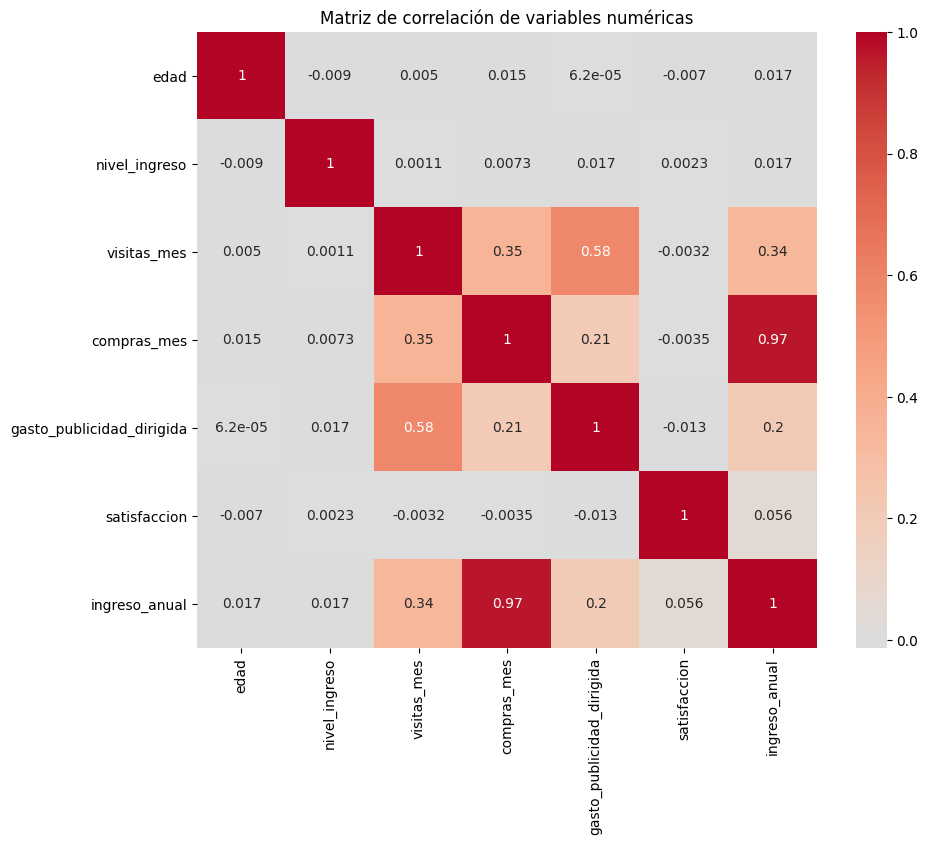

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
# Seleccionar variables numéricas
numericas = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]

# Matriz de correlación
corr_matrix = df[numericas].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación de variables numéricas')
plt.show()



Observaciones generales (Heatmap)  
- Se observa que la mayoría de las variables presentan correlaciones débiles o cercanas a cero, lo que indica poca relación lineal entre ellas.

Observaciones respecto a `ingreso_anual`:
- Presenta una correlación positiva muy fuerte con `compras_mes` (0.97), lo que sugiere que los clientes que realizan más compras tienden a generar mayores ingresos para la empresa.
- También se observa una correlación positiva moderada con `visitas_mes` (0.34), indicando que una mayor frecuencia de visitas suele estar asociada con mayores ingresos, aunque la relación es considerablemente más débil que la observada con las compras.
- `gasto_publicidad_dirigida` muestra una correlación positiva débil (0.20), mientras que `satisfaccion` presenta una relación muy débil (0.056).
- `edad` (0.017) y `nivel_ingreso` (0.017) prácticamente no muestran relación lineal con el ingreso anual generado.
- Estas correlaciones indican asociación entre variables, pero no permiten concluir que una variable cause cambios en otra. Por ejemplo, aunque existe una fuerte correlación entre compras e ingreso anual, esto no demuestra causalidad, ya que el ingreso anual podría estar calculado directamente a partir de las compras realizadas o influenciado por otros factores no incluidos en el análisis.


### Scatterplot general

Con base en los resultados del análisis de correlación, se evalúa si es necesario generar un *scatterplot* general.

En este caso, con los resultados del heatmap, sí tiene sentido generar un scatterplot, pero no uno general entre todas las variables. La mejor práctica es generar un scatterplot entre las dos variables que mostraron la correlación más fuerte:

### Scatterplot para pares clave

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes


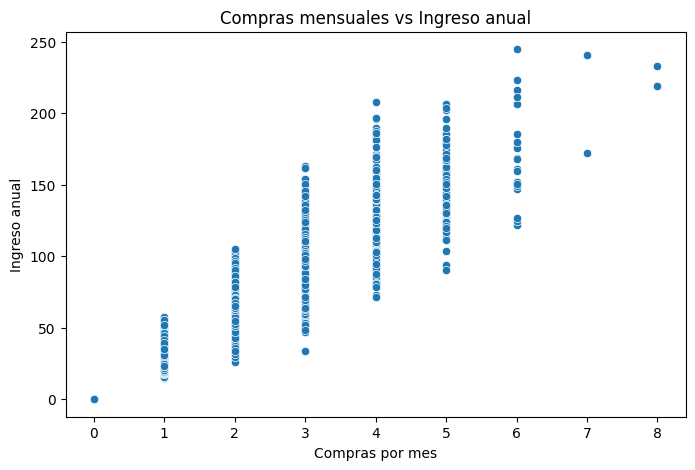

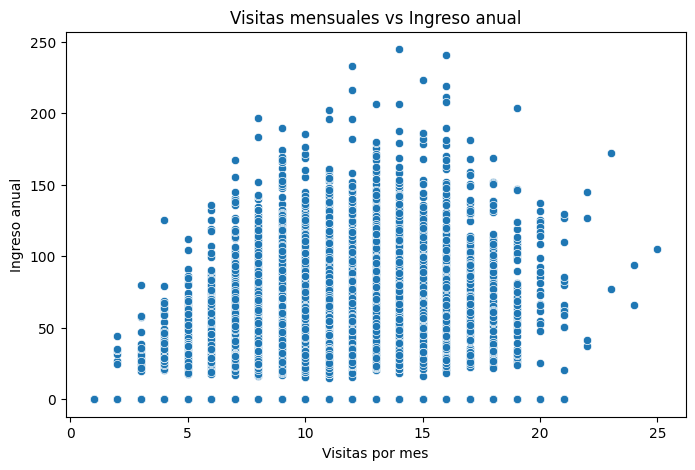

In [ ]:
# Scatterplot entre compras e ingreso_anual

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual'
)

plt.title('Compras mensuales vs Ingreso anual')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')
plt.show()

# Scatterplot entre visitas_mes e ingreso_anual

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='ingreso_anual'
)

plt.title('Visitas mensuales vs Ingreso anual')
plt.xlabel('Visitas por mes')
plt.ylabel('Ingreso anual')
plt.show()




Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**
- Dirección Positiva.
- Dispersión: Baja a media. Los puntos siguen una tendencia ascendente claramente definida, lo que indica una relación lineal fuerte entre ambas variables.
- Outliers: Se observan algunos valores altos de ingreso anual en clientes con 6, 7 y 8 compras mensuales; sin embargo, estos valores siguen la tendencia general y no parecen alterar significativamente el patrón observado.
- Posible colinealidad: Alta. La relación visual es muy fuerte y consistente con la correlación obtenida previamente (r ≈ 0.97), por lo que ambas variables comparten gran parte de la misma información.

**visitas_mes vs ingreso_anual**
- Dirección Positiva
- Dispersión: Alta. Aunque existe una tendencia ascendente, los puntos se encuentran considerablemente más dispersos, lo que indica una relación más débil que la observada entre compras e ingreso anual.
- Outliers: Se identifican algunos clientes con ingresos anuales elevados para ciertos niveles de visitas mensuales; no obstante, no se observan valores atípicos extremos que distorsionen el comportamiento general.
- Posible colinealidad: Baja. La dispersión observada y la correlación moderada (r ≈ 0.34) sugieren que no existe un problema importante de colinealidad entre estas variables.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:

# Calcular correlación entre variables relevantes

# Pearson

pearson_compras = df['compras_mes'].corr(df['ingreso_anual'], method='pearson')
pearson_visitas = df['visitas_mes'].corr(df['ingreso_anual'], method='pearson')

print("Pearson - compras vs ingreso:", pearson_compras)
print("Pearson - visitas vs ingreso:", pearson_visitas)





Pearson - compras vs ingreso: 0.9671485435708564
Pearson - visitas vs ingreso: 0.3371466432498745


In [ ]:
# Calcular correlación entre variables relevantes


# Spearman

spearman_compras = df['compras_mes'].corr(df['ingreso_anual'], method='spearman')
spearman_visitas = df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')

print("\nSpearman - compras vs ingreso:", spearman_compras)
print("Spearman - visitas vs ingreso:", spearman_visitas)




Spearman - compras vs ingreso: 0.967482492032673
Spearman - visitas vs ingreso: 0.32095369737696483


Observaciones de correlación

**compras_mes vs ingreso_anual**
- Correlación Pearson: 0.967

- Correlación Spearman: 0.967

- Dirección: Positiva.

- Magnitud: Muy fuerte. Ambos coeficientes son cercanos a 1, lo que indica una asociación muy alta entre la cantidad de compras mensuales y el ingreso anual generado.

- Posible colinealidad: Alta. Debido a la fuerza de la relación observada, estas variables comparten gran parte de la misma información. Si se construyera un modelo predictivo, sería recomendable revisar posibles problemas de colinealidad con otras variables relacionadas con el comportamiento de compra.


**visitas_mes vs ingreso_anual**
- Correlación Pearson: 0.337

- Correlación Spearman: 0.321

- Dirección: Positiva.

- Magnitud: Moderada. Existe una tendencia a que los clientes con más visitas generen mayores ingresos, aunque la relación es considerablemente más débil que la observada para las compras mensuales.

- Posible colinealidad: Baja. Los coeficientes están lejos de valores que normalmente indicarían una fuerte dependencia entre variables.



### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes

# Miembro premium vs ingreso anual
pb_premium = pointbiserialr(df["miembro_premium"], df["ingreso_anual"])

# Abandono vs ingreso anual
pb_abandono = pointbiserialr(df["abandono"], df["ingreso_anual"])

print("Punto-biserial Premium vs Ingreso:")
print(pb_premium)

print("\nPunto-biserial Abandono vs Ingreso:")
print(pb_abandono)



Punto-biserial Premium vs Ingreso:
SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

Punto-biserial Abandono vs Ingreso:
SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)


Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación: Positiva.
- Magnitud: Baja (0.093).
- Los clientes con membresía premium tienden a generar ligeramente más ingresos que los clientes que no cuentan con esta suscripción. Sin embargo, la magnitud de la relación es débil, por lo que la condición de miembro premium explica una proporción muy pequeña de la variabilidad observada en el ingreso anual.

**abandono vs ingreso_anual**
- Relación: Negativa.
- Magnitud: Muy baja o prácticamente nula (-0.0028).
- No se observa una asociación relevante entre el abandono de la plataforma y el ingreso anual generado. El coeficiente es extremadamente cercano a cero, lo que sugiere que ambas variables son prácticamente independientes dentro de este conjunto de datos.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)

    chi2, p, dof, expected = chi2_contingency(tabla)

    n = tabla.sum().sum()

    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))


In [ ]:
# Aplicar V de Cramér en variables relevantes

# Tipo de dispositivo vs Región
cv_dispositivo_region = cramers_v(df["tipo_dispositivo"], df["region"])

# Tipo de dispositivo vs Miembro premium
cv_dispositivo_premium = cramers_v(df["tipo_dispositivo"], df["miembro_premium"])

# Región vs Abandono
cv_region_abandono = cramers_v(df["region"], df["abandono"])

print("Dispositivo vs Región:", cv_dispositivo_region)
print("Dispositivo vs Premium:", cv_dispositivo_premium)
print("Región vs Abandono:", cv_region_abandono)


Dispositivo vs Región: 0.012378338407739397
Dispositivo vs Premium: 0.01972543445542166
Región vs Abandono: 0.015429712175030079


Observaciones V de Cramér:

Los coeficientes V de Cramér obtenidos son inferiores a 0.02 en todos los casos, lo que indica asociaciones muy débiles o prácticamente nulas entre las variables categóricas estudiadas. En consecuencia, no se identifican patrones relevantes de dependencia entre el tipo de dispositivo, la región, la membresía premium y el abandono. Esto sugiere que estas variables categóricas aportan poca evidencia de relación entre sí dentro del conjunto de datos analizado.




In [ ]:
#Análisis por Segmentos:

# Separar grupos
premium = df[df["miembro_premium"] == 1]
no_premium = df[df["miembro_premium"] == 0]

# Correlación compras vs ingreso
corr_premium = premium["compras_mes"].corr(premium["ingreso_anual"])
corr_no_premium = no_premium["compras_mes"].corr(no_premium["ingreso_anual"])

print("Premium:", corr_premium)
print("No Premium:", corr_no_premium)


Premium: 0.9724210114608486
No Premium: 0.974935242032698


**Comentarios**:

La correlación positiva entre la cantidad de compras mensuales y el ingreso anual se mantiene en ambos segmentos. En los dos grupos se observa una asociación muy fuerte, lo que indica que los clientes que realizan más compras tienden a generar mayores ingresos independientemente de si cuentan o no con una membresía premium.

Además, la diferencia entre los coeficientes es mínima (0.972 vs 0.974), por lo que el patrón identificado en el análisis general resulta consistente entre ambos segmentos.




## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — La frecuencia de visitas tiene una relación positiva moderada con los ingresos

**Evidencia visual:**

Scatterplot entre visitas_mes e ingreso_anual.
Heatmap de correlaciones.

**Evidencia numérica:**

Correlación de Pearson: 0.337
Correlación de Spearman: 0.321

**Interpretación**  

Los clientes que visitan con mayor frecuencia la plataforma tienden a generar mayores ingresos, aunque la relación es considerablemente más débil que la observada para las compras.

**No podemos afirmar**  

No podemos asegurar que aumentar el número de visitas genere automáticamente más ingresos, ya que podrían existir otros factores que expliquen simultáneamente ambos comportamientos.

**Implicación de negocio**  

Incrementar la interacción de los usuarios con la plataforma podría representar una oportunidad para aumentar las probabilidades de compra. Acciones orientadas a mejorar la experiencia del usuario y fomentar visitas recurrentes podrían ser beneficiosas.


### Hallazgo 2 — Las variables categóricas muestran poca asociación con el comportamiento de ingresos

**Evidencia visual:**  

Distribuciones de variables categóricas.
Resultados de V de Cramér.

**Evidencia numérica:**

Dispositivo vs Región: 0.012
Dispositivo vs Premium: 0.020
Región vs Abandono: 0.015
Premium vs Ingreso (Punto-biserial): 0.093
Abandono vs Ingreso (Punto-biserial): -0.003

**Interpretación**  

Las variables categóricas analizadas presentan asociaciones muy débiles o prácticamente inexistentes. Asimismo, la membresía premium muestra una relación positiva pero débil con los ingresos.

**No podemos afirmar**  

No podemos concluir que pertenecer al programa premium o utilizar un determinado dispositivo tenga un impacto directo sobre los ingresos generados.

**Implicación de negocio**

Los resultados sugieren que el comportamiento de compra de los clientes aporta mayor valor analítico que las variables demográficas o categóricas consideradas. Las iniciativas de negocio podrían enfocarse prioritariamente en variables relacionadas con la actividad y el compromiso de los usuarios.

### Hallazgo 3 — La frecuencia de compra es el factor más asociado con los ingresos

**Evidencia visual:**

Scatterplot entre compras_mes e ingreso_anual.
Heatmap de correlaciones donde ambas variables muestran la asociación más fuerte.

**Evidencia numérica:**

Correlación de Pearson: 0.967
Correlación de Spearman: 0.967

**Interpretación**  

Los clientes que realizan más compras mensuales tienden a generar mayores ingresos anuales para la empresa. La relación observada es positiva y muy fuerte, siendo la asociación más relevante encontrada en el análisis.

**No podemos afirmar**

No podemos concluir que incrementar artificialmente el número de compras cause directamente un aumento en los ingresos. El análisis identifica una asociación estadística, no una relación causal.

**Implicación de negocio**

Las estrategias enfocadas en aumentar la frecuencia de compra de los clientes podrían estar relacionadas con mayores ingresos para la empresa. Programas de fidelización, promociones personalizadas y campañas de recompra podrían ser líneas de acción a explorar.



## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

- Correlación ≠ causalidad Las relaciones identificadas representan asociaciones estadísticas y no permiten establecer relaciones causa-efecto.
- El análisis se realizó sobre las variables disponibles en el conjunto de datos; podrían existir factores relevantes no incluidos.
- Algunas variables pueden estar influenciadas por procesos internos de negocio que no fueron considerados en este estudio.


### **Próximos pasos**

Probar segmentación adicional:
- Analizar grupos de clientes según nivel de ingresos.
- Identificar perfiles de clientes de alto valor.

Analizar comportamiento de abandono:
- Investigar qué variables están más asociadas con el abandono.
- Identificar señales tempranas de riesgo de abandono.
- Diseñar estrategias de retención basadas en datos.

Generar recomendaciones de negocio:
- Evaluar acciones que incentiven compras recurrentes.
- Diseñar campañas segmentadas para aumentar la frecuencia de compra.
- Medir el impacto de futuras estrategias mediante experimentos controlados o pruebas A/B.